
# A/B Test Analysis: Landing Page Conversion

Analyzing an e-commerce A/B test to determine whether a new landing page design improves user conversion compared to the existing page.

**Dataset:** ~290,000 user sessions, after cleaning (Udacity A/B Testing dataset)
**Question:** Does the new landing page produce a statistically significant difference in conversion rate compared to the old page?

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Cleaning

In [5]:
df = pd.read_csv("ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [6]:
df.shape

(294478, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [8]:
df.isna().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

## Data Integrity Checks

In [10]:
df['group'].value_counts()

group
treatment    147276
control      147202
Name: count, dtype: int64

In [11]:
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [12]:
# To Keep only rows where the assigned group matches what they were actually shown
df_clean = df[((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
              ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))]

print(df_clean.shape)

(290585, 5)


In [13]:
df_clean['user_id'].duplicated().sum()

1

In [14]:
df_clean = df_clean.drop_duplicates(subset='user_id', keep='first')
print(df_clean.shape)

(290584, 5)


## Descriptive Statistics

In [16]:
conversion_rates = df_clean.groupby('group')['converted'].mean()
print(conversion_rates)

group
control      0.120386
treatment    0.118808
Name: converted, dtype: float64


## Hypothesis Testing

In [18]:
contingency_table = pd.crosstab(df_clean['group'], df_clean['converted'])
print(contingency_table)

converted       0      1
group                   
control    127785  17489
treatment  128046  17264


In [19]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print("Chi-square statistic:", chi2)
print("P-value:", p_value)

Chi-square statistic: 1.7035660051885058
P-value: 0.19182228096235662


## Confidence Interval

In [21]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

# counts of conversions and total sample size per group
control_conversions = contingency_table.loc['control', 1]
treatment_conversions = contingency_table.loc['treatment', 1]
control_n = contingency_table.loc['control'].sum()
treatment_n = contingency_table.loc['treatment'].sum()

ci_low, ci_high = confint_proportions_2indep(
    treatment_conversions, treatment_n,
    control_conversions, control_n
)

print("95% confidence interval for (treatment - control) conversion rate difference:")
print(f"({ci_low:.4f}, {ci_high:.4f})")

95% confidence interval for (treatment - control) conversion rate difference:
(-0.0039, 0.0008)


## Visualization

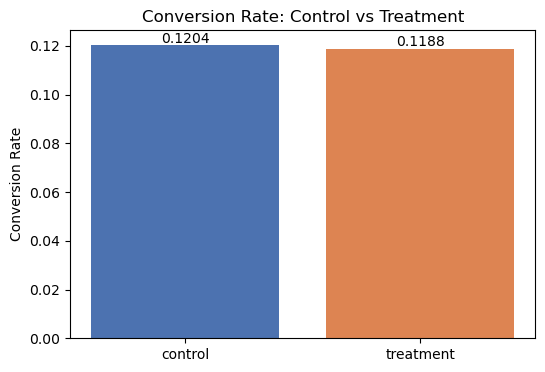

In [23]:
import matplotlib.pyplot as plt

rates = df_clean.groupby('group')['converted'].mean()

plt.figure(figsize=(6,4))
plt.bar(rates.index, rates.values, color=['#4C72B0', '#DD8452'])
plt.ylabel('Conversion Rate')
plt.title('Conversion Rate: Control vs Treatment')
for i, v in enumerate(rates.values):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center')
plt.show()

## Conclusion

Control converted at 12.04% and treatment at 11.88% — the new page performed marginally worse, not better. A chi-square test of independence returned p = 0.192, well above the 0.05 significance threshold, meaning this gap is consistent with random chance rather than a real effect. The 95% confidence interval for the difference in conversion rates, (-0.39%, +0.08%), includes zero and skews toward the new page underperforming, reinforcing that there is no statistical evidence the redesign improves conversion. Recommendation: do not ship the new page based on this data: the test shows no measurable lift, and the plausible downside outweighs the plausible upside.